In [2]:
import sys
import os
from pathlib import Path
import mlflow
import torch
import mlflow.pytorch

import numpy as np

PROJECT_ROOT = Path.cwd().parent
print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.training.setup import get_dataloaders, setup_experiment
from src.utils.scale import inverse_target



def load_torch_model_from_registry(model_name: str, device: str = "cpu"):
    """
    Loads a torch model logged with mlflow.pytorch.log_model and registered.
    """
    model_uri = f"models:/{model_name}@production"
    model = mlflow.pytorch.load_model(model_uri, map_location=device)
    model.to(device)
    model.eval()
    return model


def rmse_per_horizon(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    # y_*: [N, H]
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2, dim=0))  # [H]

def bootstrap_ci_per_horizon(errors_by_sample: np.ndarray, n_boot=300, alpha=0.05, seed=0):
    """
    errors_by_sample: shape [N, H] = per-sample absolute error etc.
    returns: mean [H], lo [H], hi [H]
    """
    rng = np.random.default_rng(seed)
    N, H = errors_by_sample.shape

    boots = np.empty((n_boot, H), dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boots[b] = errors_by_sample[idx].mean(axis=0)

    mean = errors_by_sample.mean(axis=0)
    lo = np.quantile(boots, alpha/2, axis=0)
    hi = np.quantile(boots, 1-alpha/2, axis=0)
    return mean, lo, hi

@torch.no_grad()
def predict_all(model, loader, device):
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        ys.append(y)
        ps.append(pred)
    return torch.cat(ys, dim=0), torch.cat(ps, dim=0)

@torch.no_grad()
def predict_persistence(test_loader, device, feature_idx=0):
    """
    Persistence baseline:
    predict last observed value of the TARGET FEATURE for all horizon steps.
    """
    ys, ps = [], []

    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
    
        last_val = x[:, -1, feature_idx] 
        H = y.shape[1]
        pred = last_val.unsqueeze(1).repeat(1, H)

        ys.append(y)
        ps.append(pred)

    return torch.cat(ys, dim=0), torch.cat(ps, dim=0)




Project root: /Users/arthurreuss/code/Arthurreuss/Python/RUG/AIE/NO2_Prediction


[device] Using MPS
Using feature index 10 ('nitrogen_dioxide') for Persistence.


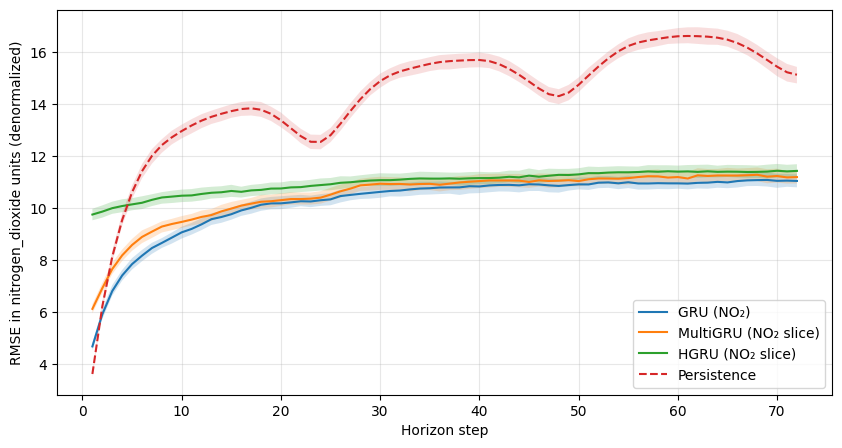

In [6]:
import matplotlib.pyplot as plt
import numpy as np

GRU_MODEL_NAME = "gru_best_model"
MULTIGRU_MODEL_NAME = "multigru_best_model"
HGRU_MODEL_NAME = "hgru_best_model"

ctx = setup_experiment("config.yaml", experiment_name="Plotting")
cfg = ctx["cfg"]
device = ctx["device"]

numeric_cols = ctx["numeric_cols"]
scaler = ctx["scaler"]

plot_target = "nitrogen_dioxide"

_, _, test_loader_single = get_dataloaders(cfg, multi_target=False)
_, _, test_loader_multi = get_dataloaders(cfg, multi_target=True)

gru = load_torch_model_from_registry(GRU_MODEL_NAME, device)
multigru = load_torch_model_from_registry(MULTIGRU_MODEL_NAME, device)
hgru = load_torch_model_from_registry(HGRU_MODEL_NAME, device)

feature_cols = cfg["data"]["feature_cols"]
target_feat_idx = feature_cols.index(plot_target)
print(f"Using feature index {target_feat_idx} ('{plot_target}') for Persistence.")

y_true_s, y_pred_gru = predict_all(gru, test_loader_single, device)
y_true_m, y_pred_mgru = predict_all(multigru, test_loader_multi, device)
y_true_h, y_pred_hgru = predict_all(hgru, test_loader_multi, device)
y_true_p, y_pred_persist = predict_persistence(test_loader_single, device, feature_idx=target_feat_idx)

t_idx = cfg["data"]["target_cols"].index(plot_target)

y_true_den_s = inverse_target(scaler, y_true_s, numeric_cols, plot_target)
y_true_den_m = inverse_target(scaler, y_true_m[..., t_idx], numeric_cols, plot_target)

y_gru_den = inverse_target(scaler, y_pred_gru, numeric_cols, plot_target)
y_mgru_den = inverse_target(scaler, y_pred_mgru[..., t_idx], numeric_cols, plot_target)
y_hgru_den = inverse_target(scaler, y_pred_hgru[..., t_idx], numeric_cols, plot_target)
y_persist_den = inverse_target(scaler, y_pred_persist, numeric_cols, plot_target)

err_gru_sq = (y_gru_den - y_true_den_s) ** 2
err_mgru_sq = (y_mgru_den - y_true_den_m) ** 2
err_hgru_sq = (y_hgru_den - y_true_den_m) ** 2
err_persist_sq = (y_persist_den - y_true_den_s) ** 2

err_gru_sq = err_gru_sq.detach().cpu().numpy()
err_mgru_sq = err_mgru_sq.detach().cpu().numpy()
err_hgru_sq = err_hgru_sq.detach().cpu().numpy()
err_persist_sq = err_persist_sq.detach().cpu().numpy()

mse_gru, mse_lo_gru, mse_hi_gru = bootstrap_ci_per_horizon(err_gru_sq, n_boot=300)
mse_mgru, mse_lo_mgru, mse_hi_mgru = bootstrap_ci_per_horizon(err_mgru_sq, n_boot=300)
mse_hgru, mse_lo_hgru, mse_hi_hgru = bootstrap_ci_per_horizon(err_hgru_sq, n_boot=300)
mse_persist, mse_lo_persist, mse_hi_persist = bootstrap_ci_per_horizon(err_persist_sq, n_boot=300)

mean_gru, lo_gru, hi_gru = np.sqrt(mse_gru), np.sqrt(mse_lo_gru), np.sqrt(mse_hi_gru)
mean_mgru, lo_mgru, hi_mgru = np.sqrt(mse_mgru), np.sqrt(mse_lo_mgru), np.sqrt(mse_hi_mgru)
mean_hgru, lo_hgru, hi_hgru = np.sqrt(mse_hgru), np.sqrt(mse_lo_hgru), np.sqrt(mse_hi_hgru)
mean_persist, lo_persist, hi_persist = np.sqrt(mse_persist), np.sqrt(mse_lo_persist), np.sqrt(mse_hi_persist)

H = len(mean_gru)
h = np.arange(1, H + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(h, mean_gru, label="GRU (NO₂)")
ax.fill_between(h, lo_gru, hi_gru, alpha=0.2)

ax.plot(h, mean_mgru, label="MultiGRU (NO₂ slice)")
ax.fill_between(h, lo_mgru, hi_mgru, alpha=0.2)

ax.plot(h, mean_hgru, label="HGRU (NO₂ slice)")
ax.fill_between(h, lo_hgru, hi_hgru, alpha=0.2)

ax.plot(h, mean_persist, label="Persistence", linestyle="--")
ax.fill_between(h, lo_persist, hi_persist, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel(f"RMSE in {plot_target} units (denormalized)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

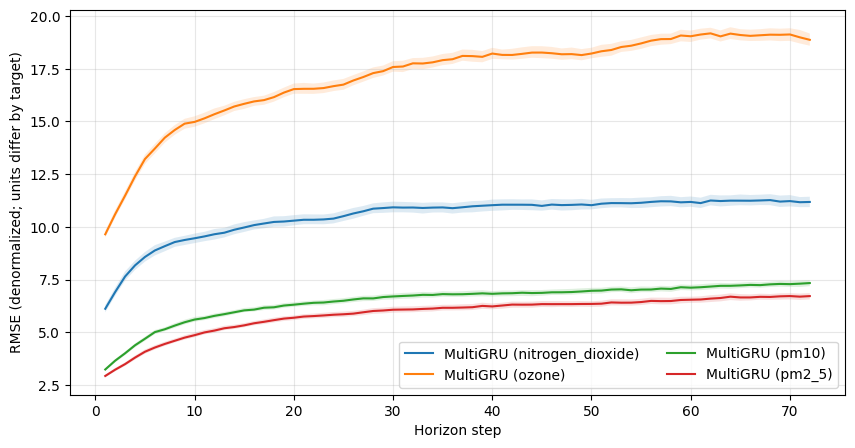

In [ ]:
# MultiGRU: per-target bootstrap bands (denormalized per target)
H = y_true_m.shape[1]
h = np.arange(1, H + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for col_name in cfg["data"]["target_cols"]:
    j = cfg["data"]["target_cols"].index(col_name)

    y_true_j = y_true_m[..., j]
    y_pred_j = y_pred_mgru[..., j]

    y_true_j_den = inverse_target(scaler, y_true_j, numeric_cols, col_name)
    y_pred_j_den = inverse_target(scaler, y_pred_j, numeric_cols, col_name)


    err_samples_sq = (y_pred_j_den - y_true_j_den) ** 2
    err_samples_sq = err_samples_sq.detach().cpu().numpy()
    
    mse_mean, mse_lo, mse_hi = bootstrap_ci_per_horizon(err_samples_sq, n_boot=300)

    rmse_mean = np.sqrt(mse_mean)
    rmse_lo   = np.sqrt(mse_lo)
    rmse_hi   = np.sqrt(mse_hi)

    ax.plot(h, rmse_mean, label=f"MultiGRU ({col_name})")
    ax.fill_between(h, rmse_lo, rmse_hi, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel("RMSE (denormalized; units differ by target)")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.show()

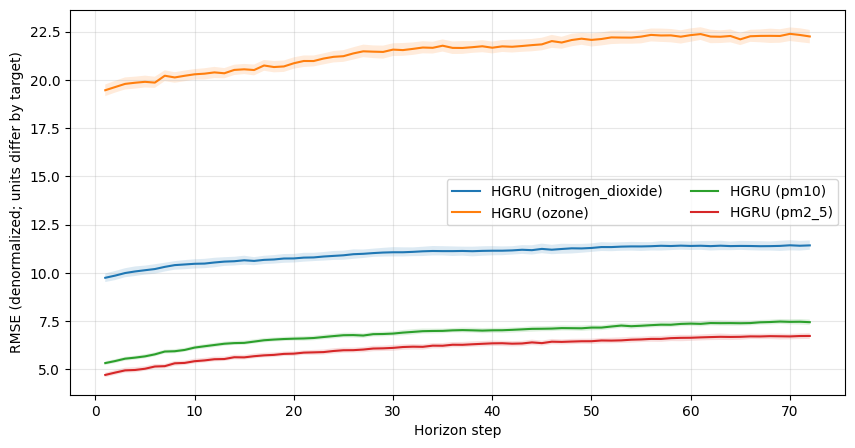

In [ ]:
# HGRU: per-target bootstrap bands (denormalized per target)
H = y_true_h.shape[1]
h = np.arange(1, H + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for col_name in cfg["data"]["target_cols"]:
    j = cfg["data"]["target_cols"].index(col_name)

    y_true_j = y_true_h[..., j]
    y_pred_j = y_pred_hgru[..., j]

    y_true_j_den = inverse_target(scaler, y_true_j, numeric_cols, col_name)
    y_pred_j_den = inverse_target(scaler, y_pred_j, numeric_cols, col_name)

    err_samples_sq = (y_pred_j_den - y_true_j_den) ** 2
    err_samples_sq = err_samples_sq.detach().cpu().numpy()
    
    mse_mean, mse_lo, mse_hi = bootstrap_ci_per_horizon(err_samples_sq, n_boot=300)
    rmse_mean = np.sqrt(mse_mean)
    rmse_lo   = np.sqrt(mse_lo)
    rmse_hi   = np.sqrt(mse_hi)

    ax.plot(h, rmse_mean, label=f"HGRU ({col_name})")
    ax.fill_between(h, rmse_lo, rmse_hi, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel("RMSE (denormalized; units differ by target)")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.show()